In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [99]:
RAW = Path("../data/raw")
PROCESSED = Path("../data/processed")
OUTPUTS = Path("../outputs")

PROCESSED.mkdir(parents=True, exist_ok=True)
OUTPUTS.mkdir(parents=True, exist_ok=True)

temp_file = RAW / "nasa_temp.csv"
co2_file = RAW / "co2.csv"
ch4_file = RAW / "ch4.csv"
n2o_file = RAW / "n2o.csv"
owid_file = RAW / "owid_co2.csv"

print("Paths ready.")

Paths ready.


In [100]:
temp_raw = pd.read_csv(temp_file, skiprows=1)
temp_raw.columns = [str(c).strip() for c in temp_raw.columns]

print(temp_raw.columns.tolist())
temp_raw.head()

['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-.09,-.16,-.10,-.21,-.18,-.10,-.14,-.23,-.22,-.19,-.17,***,***,-.12,-.17,-.20
1,1881,-0.20,-0.15,.02,.04,.07,-.19,.01,-.04,-.15,-.21,-.18,-.07,-.09,-.10,-.18,.04,-.07,-.18
2,1882,0.16,0.14,.04,-.16,-.14,-.23,-.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.08,-.09,-.16,-.18
3,1883,-0.29,-0.36,-.12,-.18,-.18,-.07,-.08,-.14,-.22,-.11,-.24,-.12,-.18,-.20,-.34,-.16,-.10,-.19
4,1884,-0.13,-0.08,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.33,-.31,-.28,-.27,-.11,-.37,-.31,-.28


In [101]:
year_col = "Year"
month_cols = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

temp = temp_raw[[year_col] + month_cols].copy()

temp = temp.melt(
    id_vars=year_col,
    value_vars=month_cols,
    var_name="month_name",
    value_name="temp_anomaly"
)

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
    "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

temp["temp_anomaly"] = temp["temp_anomaly"].replace("***", np.nan)
temp["month"] = temp["month_name"].map(month_map)
temp["year"] = pd.to_numeric(temp["Year"], errors="coerce")
temp["temp_anomaly"] = pd.to_numeric(temp["temp_anomaly"], errors="coerce")
temp["date"] = pd.to_datetime(dict(year=temp["year"], month=temp["month"], day=1), errors="coerce")

temp = temp[["date", "year", "month", "temp_anomaly"]].dropna().sort_values("date").reset_index(drop=True)

print(temp.shape)
temp.head()

(1754, 4)


,date,year,month,temp_anomaly
0,1880-01-01,1880,1,-0.19
1,1880-02-01,1880,2,-0.25
2,1880-03-01,1880,3,-0.09
3,1880-04-01,1880,4,-0.16
4,1880-05-01,1880,5,-0.10


In [102]:
def load_noaa_global_monthly(file_path, value_name):
    df = pd.read_csv(file_path, comment="#")
    df.columns = [str(c).strip().lower() for c in df.columns]

    print(f"{value_name} columns:", df.columns.tolist())

    year_col = "year" if "year" in df.columns else None
    month_col = "month" if "month" in df.columns else None

    value_col = None
    for c in ["average", "avg", "mean", "trend", "interpolated", value_name.lower(), "value"]:
        if c in df.columns:
            value_col = c
            break

    if year_col is None or month_col is None:
        raise ValueError(f"Could not find year/month columns in {file_path}")

    if value_col is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        numeric_cols = [c for c in numeric_cols if c not in [year_col, month_col]]
        if not numeric_cols:
            raise ValueError(f"Could not find value column in {file_path}")
        value_col = numeric_cols[0]

    out = df[[year_col, month_col, value_col]].copy()
    out.columns = ["year", "month", value_name]

    out["year"] = pd.to_numeric(out["year"], errors="coerce")
    out["month"] = pd.to_numeric(out["month"], errors="coerce")
    out[value_name] = pd.to_numeric(out[value_name], errors="coerce")

    out["date"] = pd.to_datetime(
        dict(year=out["year"], month=out["month"], day=1),
        errors="coerce"
    )

    out = out[["date", "year", "month", value_name]].dropna().sort_values("date").reset_index(drop=True)
    return out

In [103]:
co2 = load_noaa_global_monthly(co2_file, "co2")
ch4 = load_noaa_global_monthly(ch4_file, "ch4")
n2o = load_noaa_global_monthly(n2o_file, "n2o")

print("CO2 shape:", co2.shape)
print("CH4 shape:", ch4.shape)
print("N2O shape:", n2o.shape)

co2.head()

co2 columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
ch4 columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
n2o columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
CO2 shape: (564, 4)
CH4 shape: (509, 4)
N2O shape: (299, 4)


,date,year,month,co2
0,1979-01-01,1979,1,336.56
1,1979-02-01,1979,2,337.29
2,1979-03-01,1979,3,337.88
3,1979-04-01,1979,4,338.32
4,1979-05-01,1979,5,338.26


In [104]:
co2 = load_noaa_global_monthly(co2_file, "co2")
ch4 = load_noaa_global_monthly(ch4_file, "ch4")
n2o = load_noaa_global_monthly(n2o_file, "n2o")

print("CO2 shape:", co2.shape)
print("CH4 shape:", ch4.shape)
print("N2O shape:", n2o.shape)

co2.head()

co2 columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
ch4 columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
n2o columns: ['year', 'month', 'decimal', 'average', 'average_unc', 'trend', 'trend_unc']
CO2 shape: (564, 4)
CH4 shape: (509, 4)
N2O shape: (299, 4)


,date,year,month,co2
0,1979-01-01,1979,1,336.56
1,1979-02-01,1979,2,337.29
2,1979-03-01,1979,3,337.88
3,1979-04-01,1979,4,338.32
4,1979-05-01,1979,5,338.26


In [105]:
country_col = "country" if "country" in owid_raw.columns else "entity"
world = owid_raw[owid_raw[country_col].str.lower() == "world"].copy()

owid = world[["year", "co2"]].copy()

owid["year"] = pd.to_numeric(owid["year"], errors="coerce")
owid["co2"] = pd.to_numeric(owid["co2"], errors="coerce")

owid = owid.dropna().sort_values("year").reset_index(drop=True)

print(owid.shape)
owid.head()

(275, 2)


,year,co2
0,1750,9.305937
1,1751,9.407229
2,1752,9.505168
3,1753,9.610490
4,1754,9.733580


In [106]:
rows = []

for _, row in owid.iterrows():
    for m in range(1, 13):
        rows.append({
            "year": int(row["year"]),
            "month": m,
            "co2_emissions": row["co2"]
        })

owid_monthly = pd.DataFrame(rows)

owid_monthly["date"] = pd.to_datetime(
    dict(year=owid_monthly["year"], month=owid_monthly["month"], day=1)
)

owid_monthly = owid_monthly[["date", "year", "month", "co2_emissions"]]
owid_monthly = owid_monthly.sort_values("date").reset_index(drop=True)

print(owid_monthly.shape)
owid_monthly.head()

(3300, 4)


,date,year,month,co2_emissions
0,1750-01-01,1750,1,9.305937
1,1750-02-01,1750,2,9.305937
2,1750-03-01,1750,3,9.305937
3,1750-04-01,1750,4,9.305937
4,1750-05-01,1750,5,9.305937


In [107]:
df = temp.copy()

df = df.merge(co2[["date", "co2"]], on="date", how="left")
df = df.merge(ch4[["date", "ch4"]], on="date", how="left")
df = df.merge(n2o[["date", "n2o"]], on="date", how="left")
df = df.merge(owid_monthly[["date", "co2_emissions"]], on="date", how="left")

df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month

df = df.sort_values("date").reset_index(drop=True)

print("Shape after merge:", df.shape)
df.head()

Shape after merge: (1754, 8)


,date,year,month,temp_anomaly,co2,ch4,n2o,co2_emissions
0,1880-01-01,1880,1,-0.19,NaN,NaN,NaN,858.227783
1,1880-02-01,1880,2,-0.25,NaN,NaN,NaN,858.227783
2,1880-03-01,1880,3,-0.09,NaN,NaN,NaN,858.227783
3,1880-04-01,1880,4,-0.16,NaN,NaN,NaN,858.227783
4,1880-05-01,1880,5,-0.10,NaN,NaN,NaN,858.227783


In [108]:
print("Missing values before cleaning:")
print(df.isna().sum())

# Fill internal gaps
df = df.interpolate(numeric_only=True)

# Fill leading/trailing gaps
df = df.ffill().bfill()

print("\nShape after filling:", df.shape)

# Feature engineering
df["months_since_start"] = np.arange(len(df))

df["co2_growth_rate"] = df["co2"].diff()
df["ch4_growth_rate"] = df["ch4"].diff()
df["n2o_growth_rate"] = df["n2o"].diff()

df["co2_12mo_ma"] = df["co2"].rolling(12).mean()
df["ch4_12mo_ma"] = df["ch4"].rolling(12).mean()
df["n2o_12mo_ma"] = df["n2o"].rolling(12).mean()
df["temp_12mo_ma"] = df["temp_anomaly"].rolling(12).mean()

df = df.dropna().reset_index(drop=True)

print("\nFinal dataset shape:", df.shape)
df.head()

Missing values before cleaning:
date                0
year                0
month               0
temp_anomaly        0
co2              1190
ch4              1245
n2o              1455
co2_emissions      14
dtype: int64

Shape after filling: (1754, 8)

Final dataset shape: (1743, 16)


,date,year,month,temp_anomaly,co2,ch4,n2o,co2_emissions,months_since_start,co2_growth_rate,ch4_growth_rate,n2o_growth_rate,co2_12mo_ma,ch4_12mo_ma,n2o_12mo_ma,temp_12mo_ma
0,1880-12-01,1880,12,-0.19,336.56,1625.97,316.3,858.227783,11,0.0,0.0,0.0,336.56,1625.97,316.3,-0.171667
1,1881-01-01,1881,1,-0.20,336.56,1625.97,316.3,888.172546,12,0.0,0.0,0.0,336.56,1625.97,316.3,-0.172500
2,1881-02-01,1881,2,-0.15,336.56,1625.97,316.3,888.172546,13,0.0,0.0,0.0,336.56,1625.97,316.3,-0.164167
3,1881-03-01,1881,3,0.02,336.56,1625.97,316.3,888.172546,14,0.0,0.0,0.0,336.56,1625.97,316.3,-0.155000
4,1881-04-01,1881,4,0.04,336.56,1625.97,316.3,888.172546,15,0.0,0.0,0.0,336.56,1625.97,316.3,-0.138333


In [109]:
final_csv = PROCESSED / "final_climate_dataset.csv"
df.to_csv(final_csv, index=False)

print("Saved:", final_csv)
print("Date range:", df["date"].min(), "to", df["date"].max())
print("Shape:", df.shape)
df.head(3)

Saved: ..\data\processed\final_climate_dataset.csv
Date range: 1880-12-01 00:00:00 to 2026-02-01 00:00:00
Shape: (1743, 16)


,date,year,month,temp_anomaly,co2,ch4,n2o,co2_emissions,months_since_start,co2_growth_rate,ch4_growth_rate,n2o_growth_rate,co2_12mo_ma,ch4_12mo_ma,n2o_12mo_ma,temp_12mo_ma
0,1880-12-01,1880,12,-0.19,336.56,1625.97,316.3,858.227783,11,0.0,0.0,0.0,336.56,1625.97,316.3,-0.171667
1,1881-01-01,1881,1,-0.20,336.56,1625.97,316.3,888.172546,12,0.0,0.0,0.0,336.56,1625.97,316.3,-0.172500
2,1881-02-01,1881,2,-0.15,336.56,1625.97,316.3,888.172546,13,0.0,0.0,0.0,336.56,1625.97,316.3,-0.164167


In [110]:
features = [
    "co2",
    "ch4",
    "n2o",
    "co2_emissions",
    "months_since_start",
    "co2_growth_rate",
    "ch4_growth_rate",
    "n2o_growth_rate",
    "co2_12mo_ma",
    "ch4_12mo_ma",
    "n2o_12mo_ma"
]

X = df[features]
y = df["temp_anomaly"]

split = int(len(df) * 0.7)

X_train = X.iloc[:split]
X_test = X.iloc[split:]
y_train = y.iloc[:split]
y_test = y.iloc[split:]

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(1220, 11) (523, 11) (1220,) (523,)


In [111]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression")
print("R2:", lr_r2)
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)

Linear Regression
R2: -35.77504447100848
MAE: 1.6326806437359107
RMSE: 1.905580246097466


In [112]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest")
print("R2:", rf_r2)
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
R2: -1.6381298082726539
MAE: 0.4186493307839388
RMSE: 0.5103859603552244


In [113]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "R2": [lr_r2, rf_r2],
    "MAE": [lr_mae, rf_mae],
    "RMSE": [lr_rmse, rf_rmse]
})

results

,Model,R2,MAE,RMSE
0,Linear Regression,-35.775044,1.632681,1.905580
1,Random Forest,-1.638130,0.418649,0.510386


In [114]:
importance = pd.Series(rf.feature_importances_, index=features)
importance = importance.sort_values(ascending=False)

print(importance)

months_since_start    0.934346
co2_emissions         0.054732
co2_growth_rate       0.004506
co2_12mo_ma           0.003450
co2                   0.002966
n2o                   0.000000
ch4                   0.000000
ch4_growth_rate       0.000000
n2o_growth_rate       0.000000
ch4_12mo_ma           0.000000
n2o_12mo_ma           0.000000
dtype: float64


In [115]:
lr_coeffs = pd.Series(lr.coef_, index=features)
lr_coeffs = lr_coeffs.sort_values(key=np.abs, ascending=False)

print(lr_coeffs)

co2                   3.057437e-02
co2_growth_rate       3.035535e-02
co2_12mo_ma           1.840414e-02
months_since_start    3.188298e-04
co2_emissions         8.047227e-07
ch4                  -9.133102e-15
n2o                   2.314094e-16
ch4_12mo_ma           4.838645e-27
n2o_12mo_ma          -6.048306e-28
ch4_growth_rate       0.000000e+00
n2o_growth_rate       0.000000e+00
dtype: float64


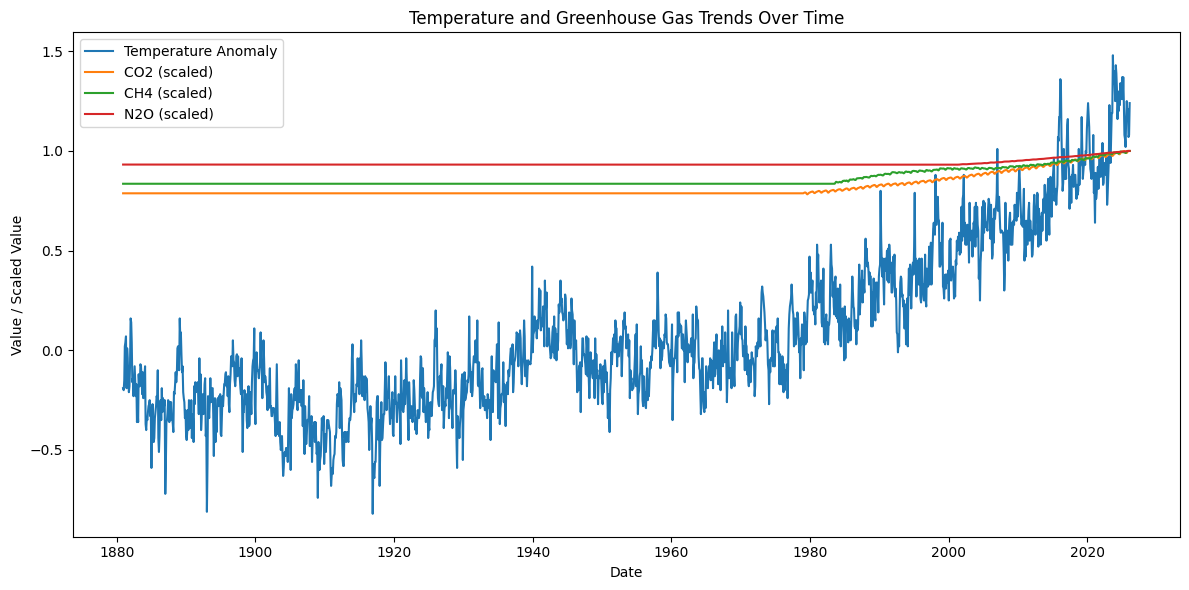

In [116]:
plt.figure(figsize=(12, 6))
plt.plot(df["date"], df["temp_anomaly"], label="Temperature Anomaly")
plt.plot(df["date"], df["co2"] / df["co2"].max(), label="CO2 (scaled)")
plt.plot(df["date"], df["ch4"] / df["ch4"].max(), label="CH4 (scaled)")
plt.plot(df["date"], df["n2o"] / df["n2o"].max(), label="N2O (scaled)")
plt.title("Temperature and Greenhouse Gas Trends Over Time")
plt.xlabel("Date")
plt.ylabel("Value / Scaled Value")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "time_series.png", dpi=300)
plt.show()

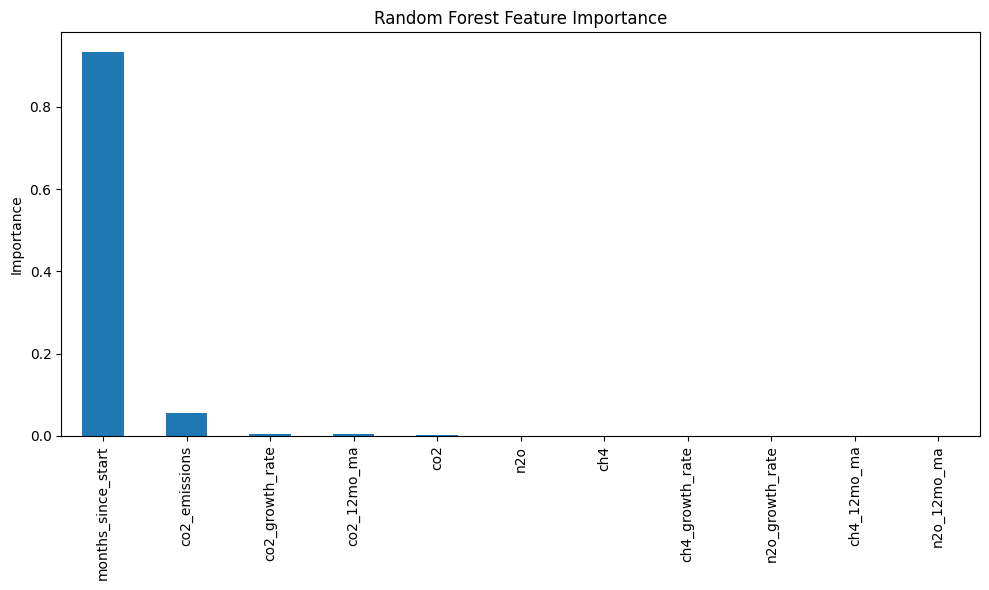

In [120]:
plt.figure(figsize=(10, 6))
importance.plot(kind="bar")
plt.title("Random Forest Feature Importance")
plt.ylabel("Importance")
plt.tight_layout()
plt.savefig(OUTPUTS / "feature_importance.png", dpi=300)
plt.show()

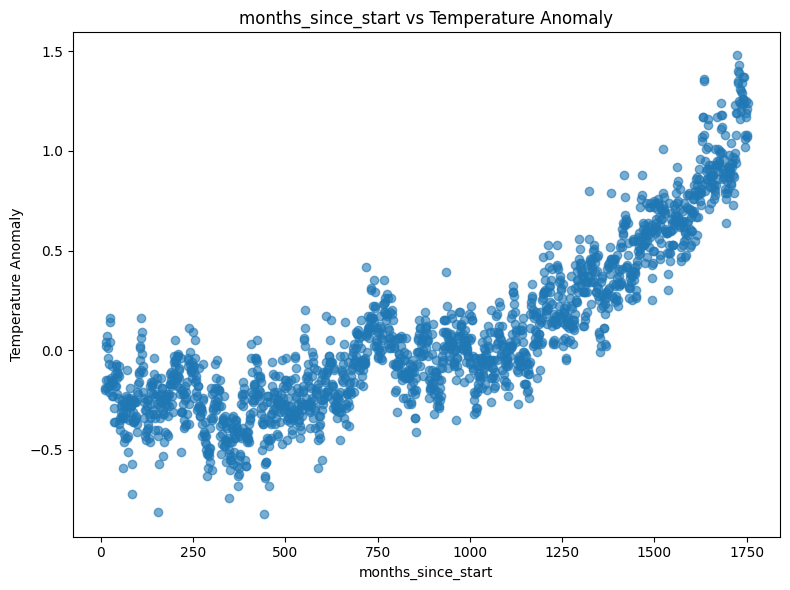

In [122]:
top_feature = importance.index[0]

plt.figure(figsize=(8, 6))
plt.scatter(df[top_feature], df["temp_anomaly"], alpha=0.6)
plt.xlabel(top_feature)
plt.ylabel("Temperature Anomaly")
plt.title(f"{top_feature} vs Temperature Anomaly")
plt.tight_layout()
plt.savefig(OUTPUTS / "top_feature_scatter.png", dpi=300)
plt.show()

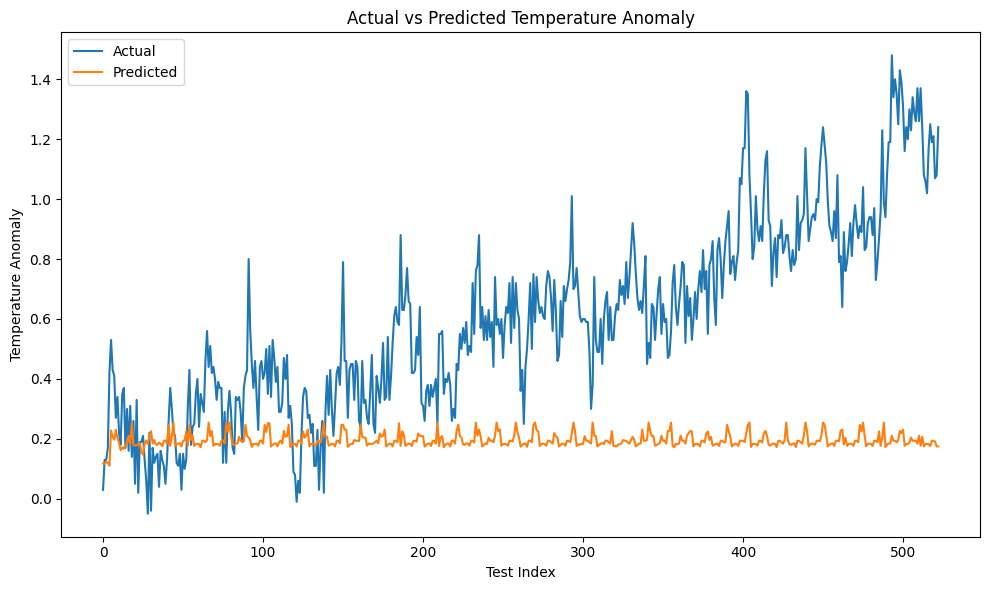

In [123]:
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred_rf, label="Predicted")
plt.title("Actual vs Predicted Temperature Anomaly")
plt.xlabel("Test Index")
plt.ylabel("Temperature Anomaly")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUTS / "actual_vs_predicted.png", dpi=300)
plt.show()

In [124]:
results.to_csv(OUTPUTS / "model_results.csv", index=False)
importance.to_csv(OUTPUTS / "random_forest_feature_importance.csv")
lr_coeffs.to_csv(OUTPUTS / "linear_regression_coefficients.csv")

print("All outputs saved.")

All outputs saved.


In [127]:
print("Final dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

print("\nFirst 3 rows:")
display(df.head(3))

print("\nModel results:")
display(results)

print("\nTop Random Forest features:")
display(importance.head(5))

print("\nTop Linear Regression coefficients:")
display(lr_coeffs.head(5))


Final dataset shape: (1743, 16)
Date range: 1880-12-01 00:00:00 to 2026-02-01 00:00:00

First 3 rows:


,date,year,month,temp_anomaly,co2,ch4,n2o,co2_emissions,months_since_start,co2_growth_rate,ch4_growth_rate,n2o_growth_rate,co2_12mo_ma,ch4_12mo_ma,n2o_12mo_ma,temp_12mo_ma
0,1880-12-01,1880,12,-0.19,336.56,1625.97,316.3,858.227783,11,0.0,0.0,0.0,336.56,1625.97,316.3,-0.171667
1,1881-01-01,1881,1,-0.20,336.56,1625.97,316.3,888.172546,12,0.0,0.0,0.0,336.56,1625.97,316.3,-0.172500
2,1881-02-01,1881,2,-0.15,336.56,1625.97,316.3,888.172546,13,0.0,0.0,0.0,336.56,1625.97,316.3,-0.164167



Model results:


,Model,R2,MAE,RMSE
0,Linear Regression,-35.775044,1.632681,1.905580
1,Random Forest,-1.638130,0.418649,0.510386



Top Random Forest features:


months_since_start    0.934346
co2_emissions         0.054732
co2_growth_rate       0.004506
co2_12mo_ma           0.003450
co2                   0.002966
dtype: float64


Top Linear Regression coefficients:


co2                   3.057437e-02
co2_growth_rate       3.035535e-02
co2_12mo_ma           1.840414e-02
months_since_start    3.188298e-04
co2_emissions         8.047227e-07
dtype: float64